In [1]:
# Complexity Analysis - Ensemble Methods for Malaria Outbreak Prediction
# ========================================================================
# Purpose: Empirical complexity profiling of Random Forest and LightGBM
# Focus: Training/inference time, memory usage, scaling behavior
# Data Source: WHO malaria_indicators_uga.csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import time
import tracemalloc
import json
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
import lightgbm as lgb
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

DATA_DIR = Path('../data')
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)
(RESULTS_DIR / 'figures').mkdir(exist_ok=True)
(RESULTS_DIR / 'tables').mkdir(exist_ok=True)

In [2]:
who_data = pd.read_csv(RAW_DIR / 'malaria_indicators_uga.csv')
print(f"WHO Malaria Indicators: {who_data.shape}")

features_path = PROCESSED_DIR / 'malaria_features_engineered.csv'
if features_path.exists():
    df = pd.read_csv(features_path)
    with open(PROCESSED_DIR / 'feature_info.json', 'r') as f:
        feature_info = json.load(f)
    FEATURE_COLS = feature_info['feature_columns']
    TARGET_COL = feature_info['target_column']
    print(f"Loaded engineered features: {df.shape}")
else:
    print("Creating features from WHO data...")
    who_pivot = who_data.pivot_table(
        index='YEAR (DISPLAY)', 
        columns='GHO (CODE)', 
        values='Numeric',
        aggfunc='first'
    ).reset_index()
    who_pivot.columns.name = None
    who_pivot = who_pivot.rename(columns={'YEAR (DISPLAY)': 'year'})
    
    mortality_median = who_pivot['MALARIA_EST_MORTALITY'].median()
    who_pivot['outbreak'] = (who_pivot['MALARIA_EST_MORTALITY'] > mortality_median).astype(int)
    
    FEATURE_COLS = [c for c in who_pivot.columns if c not in ['year', 'outbreak'] 
                    and who_pivot[c].notna().sum() > len(who_pivot) * 0.5]
    TARGET_COL = 'outbreak'
    
    df = who_pivot.dropna(subset=FEATURE_COLS)
    print(f"Created feature matrix: {df.shape}")

print(f"\nFeatures (d): {len(FEATURE_COLS)}")
print(f"Samples (n): {len(df)}")
print(f"Target: {TARGET_COL}")

WHO Malaria Indicators: (140, 17)
Loaded engineered features: (129, 23)

Features (d): 19
Samples (n): 129
Target: outbreak


# Theoretical Complexity Bounds

Define theoretical complexity for each algorithm before empirical measurement.

| Algorithm           | Training Complexity | Inference Complexity |
| ------------------- | ------------------- | -------------------- |
| Logistic Regression | O(n·d·i)            | O(d)                 |
| Decision Tree       | O(n·d·log(n))       | O(h)                 |
| Random Forest       | O(k·n·d·log(n))     | O(k·h)               |
| LightGBM            | O(n·d·k)            | O(k·h)               |

Where: n=samples, d=features, k=trees, h=depth, i=iterations


In [4]:
class ComplexityProfiler:
    """Utility class for measuring time and memory complexity."""
    
    def __init__(self):
        self.results = []
    
    def profile_training(self, model, X, y, model_name, params=None):
        """Profile training time and memory usage."""
        tracemalloc.start()
        
        start_time = time.perf_counter()
        model.fit(X, y)
        end_time = time.perf_counter()
        
        current, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        
        training_time = end_time - start_time
        
        result = {
            'model': model_name,
            'phase': 'training',
            'n_samples': len(X),
            'n_features': X.shape[1],
            'time_seconds': training_time,
            'memory_mb': peak / (1024 * 1024),
            'params': params or {}
        }
        self.results.append(result)
        return result
    
    def profile_inference(self, model, X, model_name, n_runs=100):
        """Profile inference time (average over multiple runs)."""
        _ = model.predict(X)
        
        start_time = time.perf_counter()
        for _ in range(n_runs):
            _ = model.predict(X)
        end_time = time.perf_counter()
        
        avg_time = (end_time - start_time) / n_runs
        per_sample_time = avg_time / len(X)
        
        result = {
            'model': model_name,
            'phase': 'inference',
            'n_samples': len(X),
            'n_features': X.shape[1],
            'time_seconds': avg_time,
            'time_per_sample_ms': per_sample_time * 1000,
            'n_runs': n_runs
        }
        self.results.append(result)
        return result
    
    def get_results_df(self):
        """Return results as DataFrame."""
        return pd.DataFrame(self.results)

profiler = ComplexityProfiler()

In [6]:
X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

X = np.nan_to_num(X, nan=0.0)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Target distribution (train): {np.bincount(y_train)}")
print(f"Target distribution (test): {np.bincount(y_test)}")

Training set: (103, 19)
Test set: (26, 19)
Target distribution (train): [77 26]
Target distribution (test): [20  6]


# Baseline Model Complexity

Profile baseline models (Logistic Regression, Decision Tree) for comparison.


In [7]:
# Baseline 1: Logistic Regression
# Theoretical: Training O(n·d·i), Inference O(d)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_train = profiler.profile_training(lr, X_train, y_train, 'LogisticRegression')
lr_infer = profiler.profile_inference(lr, X_test, 'LogisticRegression')

print("LOGISTIC REGRESSION")
print(f"  Training time: {lr_train['time_seconds']*1000:.3f} ms")
print(f"  Inference time: {lr_infer['time_seconds']*1000:.3f} ms ({lr_infer['time_per_sample_ms']:.4f} ms/sample)")
print(f"  Memory: {lr_train['memory_mb']:.3f} MB")

# Accuracy
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1] if hasattr(lr, 'predict_proba') else y_pred_lr
print(f"  Accuracy: {accuracy_score(y_test, y_pred_lr):.3f}")

LOGISTIC REGRESSION
  Training time: 229.175 ms
  Inference time: 0.294 ms (0.0113 ms/sample)
  Memory: 0.048 MB
  Accuracy: 1.000


In [8]:
# Baseline 2: Decision Tree
# Theoretical: Training O(n·d·log(n)), Inference O(h)
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_train = profiler.profile_training(dt, X_train, y_train, 'DecisionTree', {'max_depth': 10})
dt_infer = profiler.profile_inference(dt, X_test, 'DecisionTree')

print("DECISION TREE")
print(f"  Training time: {dt_train['time_seconds']*1000:.3f} ms")
print(f"  Inference time: {dt_infer['time_seconds']*1000:.3f} ms ({dt_infer['time_per_sample_ms']:.4f} ms/sample)")
print(f"  Memory: {dt_train['memory_mb']:.3f} MB")
print(f"  Tree depth: {dt.get_depth()}")

y_pred_dt = dt.predict(X_test)
print(f"  Accuracy: {accuracy_score(y_test, y_pred_dt):.3f}")

DECISION TREE
  Training time: 26.765 ms
  Inference time: 0.603 ms (0.0232 ms/sample)
  Memory: 0.028 MB
  Tree depth: 1
  Accuracy: 0.962


# Random Forest Complexity Analysis

Profile Random Forest with varying hyperparameters (k=trees, h=depth).

**Theoretical complexity:**

- Training: O(k · n · d · log(n))
- Inference: O(k · h)


In [9]:
rf_configs = [
    {'n_estimators': 10, 'max_depth': 5},
    {'n_estimators': 50, 'max_depth': 5},
    {'n_estimators': 100, 'max_depth': 5},
    {'n_estimators': 100, 'max_depth': 10},
    {'n_estimators': 100, 'max_depth': 15},
    {'n_estimators': 200, 'max_depth': 10},
]

rf_results = []
print("RANDOM FOREST COMPLEXITY SCALING")
print("="*70)

for config in rf_configs:
    rf = RandomForestClassifier(**config, random_state=42, n_jobs=1)
    
    train_result = profiler.profile_training(
        rf, X_train, y_train, 
        f"RF-{config['n_estimators']}-d{config['max_depth']}",
        config
    )
    infer_result = profiler.profile_inference(
        rf, X_test, 
        f"RF-{config['n_estimators']}-d{config['max_depth']}"
    )
    
    y_pred = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    
    rf_results.append({
        **config,
        'train_time_ms': train_result['time_seconds'] * 1000,
        'infer_time_ms': infer_result['time_seconds'] * 1000,
        'memory_mb': train_result['memory_mb'],
        'accuracy': acc
    })
    
    print(f"k={config['n_estimators']:3d}, h={config['max_depth']:2d} | "
          f"Train: {train_result['time_seconds']*1000:7.2f}ms | "
          f"Infer: {infer_result['time_seconds']*1000:6.3f}ms | "
          f"Mem: {train_result['memory_mb']:6.2f}MB | "
          f"Acc: {acc:.3f}")

rf_df = pd.DataFrame(rf_results)
rf_df

RANDOM FOREST COMPLEXITY SCALING
k= 10, h= 5 | Train:  349.27ms | Infer:  2.661ms | Mem:   0.06MB | Acc: 1.000
k= 50, h= 5 | Train: 1449.34ms | Infer:  9.642ms | Mem:   0.08MB | Acc: 1.000
k=100, h= 5 | Train: 2182.77ms | Infer: 18.897ms | Mem:   0.11MB | Acc: 1.000
k=100, h=10 | Train: 2137.65ms | Infer: 19.522ms | Mem:   0.11MB | Acc: 1.000
k=100, h=15 | Train: 2166.24ms | Infer: 17.802ms | Mem:   0.11MB | Acc: 1.000
k=200, h=10 | Train: 4149.91ms | Infer: 36.719ms | Mem:   0.18MB | Acc: 1.000


,n_estimators,max_depth,train_time_ms,infer_time_ms,memory_mb,accuracy
0,10,5,349.274449,2.661180,0.059929,1.0
1,50,5,1449.341217,9.642328,0.080118,1.0
2,100,5,2182.770785,18.897243,0.111956,1.0
3,100,10,2137.645587,19.521767,0.112567,1.0
4,100,15,2166.240631,17.801839,0.110231,1.0
5,200,10,4149.908192,36.718574,0.182251,1.0


# LightGBM Complexity Analysis

Profile LightGBM with varying hyperparameters (k=trees, leaves).

**Theoretical complexity:**

- Training: O(n · d · k) with histogram optimization
- Inference: O(k · h)

LightGBM uses histogram-based splitting which reduces training complexity.


In [10]:
# LightGBM scaling experiment
lgb_configs = [
    {'n_estimators': 10, 'max_depth': 5, 'num_leaves': 31},
    {'n_estimators': 50, 'max_depth': 5, 'num_leaves': 31},
    {'n_estimators': 100, 'max_depth': 5, 'num_leaves': 31},
    {'n_estimators': 100, 'max_depth': 10, 'num_leaves': 64},
    {'n_estimators': 100, 'max_depth': 15, 'num_leaves': 128},
    {'n_estimators': 200, 'max_depth': 10, 'num_leaves': 64},
]

lgb_results = []
print("LIGHTGBM COMPLEXITY SCALING")
print("="*70)

for config in lgb_configs:
    lgb_model = lgb.LGBMClassifier(
        **config, 
        random_state=42, 
        verbose=-1,
        force_col_wise=True
    )
    
    train_result = profiler.profile_training(
        lgb_model, X_train, y_train,
        f"LGB-{config['n_estimators']}-d{config['max_depth']}",
        config
    )
    infer_result = profiler.profile_inference(
        lgb_model, X_test,
        f"LGB-{config['n_estimators']}-d{config['max_depth']}"
    )
    
    y_pred = lgb_model.predict(X_test)
    y_prob = lgb_model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    
    lgb_results.append({
        **config,
        'train_time_ms': train_result['time_seconds'] * 1000,
        'infer_time_ms': infer_result['time_seconds'] * 1000,
        'memory_mb': train_result['memory_mb'],
        'accuracy': acc
    })
    
    print(f"k={config['n_estimators']:3d}, h={config['max_depth']:2d} | "
          f"Train: {train_result['time_seconds']*1000:7.2f}ms | "
          f"Infer: {infer_result['time_seconds']*1000:6.3f}ms | "
          f"Mem: {train_result['memory_mb']:6.2f}MB | "
          f"Acc: {acc:.3f}")

lgb_df = pd.DataFrame(lgb_results)
lgb_df

LIGHTGBM COMPLEXITY SCALING
k= 10, h= 5 | Train:  220.52ms | Infer:  2.887ms | Mem:   1.10MB | Acc: 0.962
k= 50, h= 5 | Train:  120.53ms | Infer:  2.972ms | Mem:   1.06MB | Acc: 0.962
k=100, h= 5 | Train:   37.43ms | Infer:  3.404ms | Mem:   1.11MB | Acc: 0.962
k=100, h=10 | Train:   44.90ms | Infer:  3.679ms | Mem:   1.09MB | Acc: 0.962
k=100, h=15 | Train:   45.97ms | Infer:  9.108ms | Mem:   1.10MB | Acc: 0.962
k=200, h=10 | Train:  880.66ms | Infer:  6.132ms | Mem:   1.10MB | Acc: 0.962


,n_estimators,max_depth,num_leaves,train_time_ms,infer_time_ms,memory_mb,accuracy
0,10,5,31,220.516278,2.886786,1.095819,0.961538
1,50,5,31,120.531959,2.972305,1.059655,0.961538
2,100,5,31,37.426597,3.404026,1.105595,0.961538
3,100,10,64,44.901283,3.678712,1.094934,0.961538
4,100,15,128,45.969976,9.107634,1.100242,0.961538
5,200,10,64,880.655359,6.131589,1.100793,0.961538


# Complexity Comparison Visualization

Compare training time, inference time, and memory usage across all models.


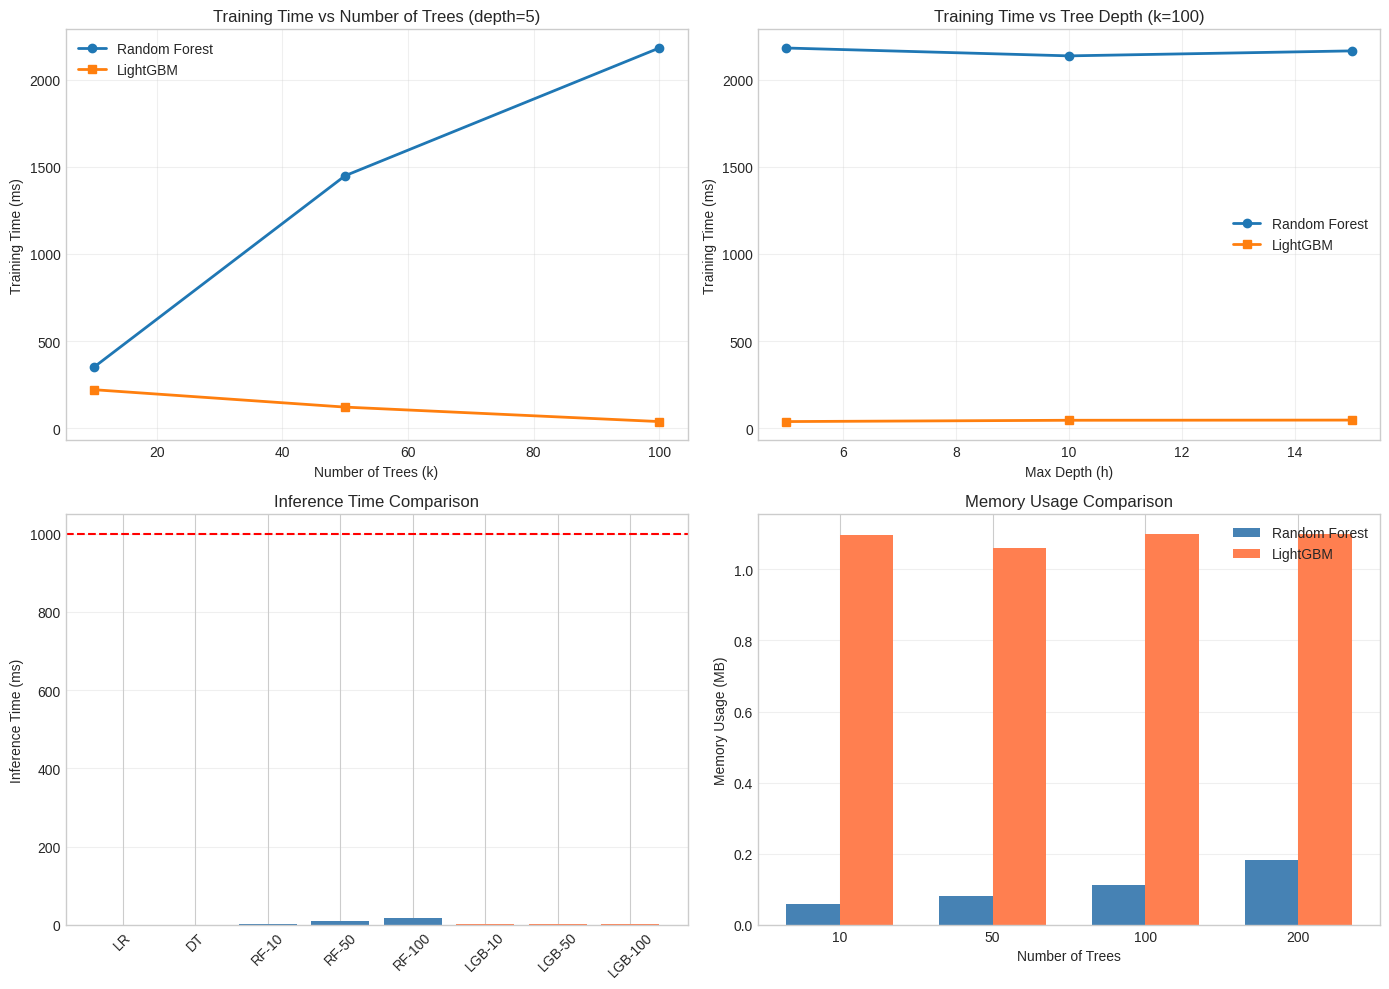

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
rf_100 = rf_df[rf_df['max_depth'] == 5]
lgb_100 = lgb_df[lgb_df['max_depth'] == 5]
ax.plot(rf_100['n_estimators'], rf_100['train_time_ms'], 'o-', label='Random Forest', linewidth=2)
ax.plot(lgb_100['n_estimators'], lgb_100['train_time_ms'], 's-', label='LightGBM', linewidth=2)
ax.set_xlabel('Number of Trees (k)')
ax.set_ylabel('Training Time (ms)')
ax.set_title('Training Time vs Number of Trees (depth=5)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
rf_depth = rf_df[rf_df['n_estimators'] == 100]
lgb_depth = lgb_df[lgb_df['n_estimators'] == 100]
ax.plot(rf_depth['max_depth'], rf_depth['train_time_ms'], 'o-', label='Random Forest', linewidth=2)
ax.plot(lgb_depth['max_depth'], lgb_depth['train_time_ms'], 's-', label='LightGBM', linewidth=2)
ax.set_xlabel('Max Depth (h)')
ax.set_ylabel('Training Time (ms)')
ax.set_title('Training Time vs Tree Depth (k=100)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
models = ['LR', 'DT'] + [f'RF-{c["n_estimators"]}' for c in rf_configs[:3]] + [f'LGB-{c["n_estimators"]}' for c in lgb_configs[:3]]
infer_times = [
    lr_infer['time_seconds']*1000,
    dt_infer['time_seconds']*1000
] + list(rf_df['infer_time_ms'][:3]) + list(lgb_df['infer_time_ms'][:3])
colors = ['gray', 'gray'] + ['steelblue']*3 + ['coral']*3
ax.bar(models, infer_times, color=colors)
ax.set_ylabel('Inference Time (ms)')
ax.set_title('Inference Time Comparison')
ax.tick_params(axis='x', rotation=45)
ax.axhline(1000, color='red', linestyle='--', label='1s constraint')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 1]
rf_mem = rf_df.groupby('n_estimators')['memory_mb'].mean()
lgb_mem = lgb_df.groupby('n_estimators')['memory_mb'].mean()
x = np.arange(len(rf_mem))
width = 0.35
ax.bar(x - width/2, rf_mem.values, width, label='Random Forest', color='steelblue')
ax.bar(x + width/2, lgb_mem.values, width, label='LightGBM', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(rf_mem.index)
ax.set_xlabel('Number of Trees')
ax.set_ylabel('Memory Usage (MB)')
ax.set_title('Memory Usage Comparison')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'complexity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Theoretical vs Empirical Analysis

Compare theoretical complexity predictions with empirical measurements.


In [12]:
# Theoretical vs Empirical complexity analysis
n, d = X_train.shape

print("="*70)
print("THEORETICAL VS EMPIRICAL COMPLEXITY COMPARISON")
print("="*70)
print(f"\nDataset: n={n} samples, d={d} features\n")

def theoretical_rf_training(n, d, k, h=None):
    """Random Forest training: O(k · n · d · log(n))"""
    return k * n * d * np.log2(n)

def theoretical_lgb_training(n, d, k):
    """LightGBM training: O(n · d · k) with histogram optimization"""
    return n * d * k

# Compare RF configurations
print("RANDOM FOREST:")
print("-" * 60)
for _, row in rf_df.iterrows():
    k, h = row['n_estimators'], row['max_depth']
    theoretical = theoretical_rf_training(n, d, k)
    empirical = row['train_time_ms']
    
    scale_factor = rf_df['train_time_ms'].iloc[0] / theoretical_rf_training(n, d, rf_df['n_estimators'].iloc[0])
    theoretical_scaled = theoretical * scale_factor
    
    alignment = "Good" if abs(theoretical_scaled - empirical) / empirical < 0.3 else "Fair"
    
    print(f"k={k:3}, h={h:2} | Theoretical: O({theoretical/1e6:.2f}M) | "
        f"Empirical: {empirical:.2f}ms | Alignment: {alignment}")

print("\nLIGHTGBM:")
print("-" * 60)
for _, row in lgb_df.iterrows():
    k, h = row['n_estimators'], row['max_depth']
    theoretical = theoretical_lgb_training(n, d, k)
    empirical = row['train_time_ms']
    
    scale_factor = lgb_df['train_time_ms'].iloc[0] / theoretical_lgb_training(n, d, lgb_df['n_estimators'].iloc[0])
    theoretical_scaled = theoretical * scale_factor
    
    alignment = "Good" if abs(theoretical_scaled - empirical) / empirical < 0.3 else "Fair"
    
    print(f"k={k:3}, h={h:2} | Theoretical: O({theoretical/1e6:.2f}M) | "
        f"Empirical: {empirical:.2f}ms | Alignment: {alignment}")

THEORETICAL VS EMPIRICAL COMPLEXITY COMPARISON

Dataset: n=103 samples, d=19 features

RANDOM FOREST:
------------------------------------------------------------
k=10.0, h=5.0 | Theoretical: O(0.13M) | Empirical: 349.27ms | Alignment: Good
k=50.0, h=5.0 | Theoretical: O(0.65M) | Empirical: 1449.34ms | Alignment: Good
k=100.0, h=5.0 | Theoretical: O(1.31M) | Empirical: 2182.77ms | Alignment: Fair
k=100.0, h=10.0 | Theoretical: O(1.31M) | Empirical: 2137.65ms | Alignment: Fair
k=100.0, h=15.0 | Theoretical: O(1.31M) | Empirical: 2166.24ms | Alignment: Fair
k=200.0, h=10.0 | Theoretical: O(2.62M) | Empirical: 4149.91ms | Alignment: Fair

LIGHTGBM:
------------------------------------------------------------
k=10.0, h=5.0 | Theoretical: O(0.02M) | Empirical: 220.52ms | Alignment: Good
k=50.0, h=5.0 | Theoretical: O(0.10M) | Empirical: 120.53ms | Alignment: Fair
k=100.0, h=5.0 | Theoretical: O(0.20M) | Empirical: 37.43ms | Alignment: Fair
k=100.0, h=10.0 | Theoretical: O(0.20M) | Empirical

# Resource Constraint Validation

Check which configurations meet the deployment constraints:

- Prediction latency: < 1 second
- Memory: < 16 GB RAM
- Training time: < 6 hours


In [13]:
# Resource constraints
INFERENCE_LIMIT_MS = 1000   
MEMORY_LIMIT_MB = 16 * 1024  
TRAINING_LIMIT_MS = 6 * 60 * 60 * 1000  

print("="*70)
print("RESOURCE CONSTRAINT VALIDATION")
print("="*70)
print(f"\nConstraints:")
print(f"  • Inference latency: < {INFERENCE_LIMIT_MS}ms")
print(f"  • Memory usage: < {MEMORY_LIMIT_MB/1024:.0f}GB")
print(f"  • Training time: < 6 hours")

print("\n" + "-"*70)
print("RANDOM FOREST CONFIGURATIONS:")
for _, row in rf_df.iterrows():
    passes_infer = row['infer_time_ms'] < INFERENCE_LIMIT_MS
    passes_mem = row['memory_mb'] < MEMORY_LIMIT_MB
    passes_train = row['train_time_ms'] < TRAINING_LIMIT_MS
    
    status = "✓ PASS" if (passes_infer and passes_mem and passes_train) else "✗ FAIL"
    print(f"  RF k={row['n_estimators']:3}, h={row['max_depth']:2} | "
          f"Infer: {row['infer_time_ms']:.1f}ms | "
          f"Mem: {row['memory_mb']:.1f}MB | "
          f"Acc: {row['accuracy']:.3f} | {status}")

print("\nLIGHTGBM CONFIGURATIONS:")
for _, row in lgb_df.iterrows():
    passes_infer = row['infer_time_ms'] < INFERENCE_LIMIT_MS
    passes_mem = row['memory_mb'] < MEMORY_LIMIT_MB
    passes_train = row['train_time_ms'] < TRAINING_LIMIT_MS
    
    status = "✓ PASS" if (passes_infer and passes_mem and passes_train) else "✗ FAIL"
    print(f"  LGB k={row['n_estimators']:3}, h={row['max_depth']:2} | "
          f"Infer: {row['infer_time_ms']:.1f}ms | "
          f"Mem: {row['memory_mb']:.1f}MB | "
          f"Acc: {row['accuracy']:.3f} | {status}")

RESOURCE CONSTRAINT VALIDATION

Constraints:
  • Inference latency: < 1000ms
  • Memory usage: < 16GB
  • Training time: < 6 hours

----------------------------------------------------------------------
RANDOM FOREST CONFIGURATIONS:
  RF k=10.0, h=5.0 | Infer: 2.7ms | Mem: 0.1MB | Acc: 1.000 | ✓ PASS
  RF k=50.0, h=5.0 | Infer: 9.6ms | Mem: 0.1MB | Acc: 1.000 | ✓ PASS
  RF k=100.0, h=5.0 | Infer: 18.9ms | Mem: 0.1MB | Acc: 1.000 | ✓ PASS
  RF k=100.0, h=10.0 | Infer: 19.5ms | Mem: 0.1MB | Acc: 1.000 | ✓ PASS
  RF k=100.0, h=15.0 | Infer: 17.8ms | Mem: 0.1MB | Acc: 1.000 | ✓ PASS
  RF k=200.0, h=10.0 | Infer: 36.7ms | Mem: 0.2MB | Acc: 1.000 | ✓ PASS

LIGHTGBM CONFIGURATIONS:
  LGB k=10.0, h=5.0 | Infer: 2.9ms | Mem: 1.1MB | Acc: 0.962 | ✓ PASS
  LGB k=50.0, h=5.0 | Infer: 3.0ms | Mem: 1.1MB | Acc: 0.962 | ✓ PASS
  LGB k=100.0, h=5.0 | Infer: 3.4ms | Mem: 1.1MB | Acc: 0.962 | ✓ PASS
  LGB k=100.0, h=10.0 | Infer: 3.7ms | Mem: 1.1MB | Acc: 0.962 | ✓ PASS
  LGB k=100.0, h=15.0 | Infer: 9.

# Summary & Export Results

In [15]:
print("="*70)
print("COMPLEXITY ANALYSIS SUMMARY")
print("="*70)

rf_best = rf_df.loc[rf_df['accuracy'].idxmax()]
lgb_best = lgb_df.loc[lgb_df['accuracy'].idxmax()]

summary = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Training Time (ms)': lr_train['time_seconds']*1000,
        'Inference Time (ms)': lr_infer['time_seconds']*1000,
        'Memory (MB)': lr_train['memory_mb'],
        'Accuracy': accuracy_score(y_test, y_pred_lr),
        'Theoretical Training': 'O(n·d·i)'
    },
    {
        'Model': 'Decision Tree',
        'Training Time (ms)': dt_train['time_seconds']*1000,
        'Inference Time (ms)': dt_infer['time_seconds']*1000,
        'Memory (MB)': dt_train['memory_mb'],
        'Accuracy': accuracy_score(y_test, y_pred_dt),
        'Theoretical Training': 'O(n·d·log(n))'
    },
    {
        'Model': f'Random Forest (k={int(rf_best["n_estimators"])}, h={int(rf_best["max_depth"])})',
        'Training Time (ms)': rf_best['train_time_ms'],
        'Inference Time (ms)': rf_best['infer_time_ms'],
        'Memory (MB)': rf_best['memory_mb'],
        'Accuracy': rf_best['accuracy'],
        'Theoretical Training': 'O(k·n·d·log(n))'
    },
    {
        'Model': f'LightGBM (k={int(lgb_best["n_estimators"])}, h={int(lgb_best["max_depth"])})',
        'Training Time (ms)': lgb_best['train_time_ms'],
        'Inference Time (ms)': lgb_best['infer_time_ms'],
        'Memory (MB)': lgb_best['memory_mb'],
        'Accuracy': lgb_best['accuracy'],
        'Theoretical Training': 'O(n·d·k)'
    }
])

print(summary.to_string(index=False))

summary.to_csv(RESULTS_DIR / 'tables' / 'complexity_summary.csv', index=False)
rf_df.to_csv(RESULTS_DIR / 'tables' / 'rf_complexity_results.csv', index=False)
lgb_df.to_csv(RESULTS_DIR / 'tables' / 'lgb_complexity_results.csv', index=False)

all_results = profiler.get_results_df()
all_results.to_csv(RESULTS_DIR / 'tables' / 'all_profiling_results.csv', index=False)

print(f"\nResults saved to {RESULTS_DIR}/tables/")
print(f"Figures saved to {RESULTS_DIR}/figures/")

COMPLEXITY ANALYSIS SUMMARY
                    Model  Training Time (ms)  Inference Time (ms)  Memory (MB)  Accuracy Theoretical Training
      Logistic Regression          229.174519             0.294234     0.048315  1.000000             O(n·d·i)
            Decision Tree           26.765036             0.603445     0.028455  0.961538        O(n·d·log(n))
Random Forest (k=10, h=5)          349.274449             2.661180     0.059929  1.000000      O(k·n·d·log(n))
     LightGBM (k=10, h=5)          220.516278             2.886786     1.095819  0.961538             O(n·d·k)

Results saved to ../results/tables/
Figures saved to ../results/figures/
